# Case Studies - Project 2: Forecasting COVID-19 cases with ML

**Part (a):** one-step-ahead $\hat{y}_{t+1}$ using lags of `log_cases` only.
**Part (b):** one-step-ahead $\hat{y}_{t+1}$ using lags of `log_cases` plus covariates.

Methods: regression tree (`DecisionTreeRegressor`) and neural network (`MLPRegressor`).
Max lag $n=10$ for $y$ and for every covariate (fixed by the assignment).

**Evaluation:** fixed 80% train / 20% test split, chronological (no shuffling). The last
20% of the 80% training block is a validation slice used only for hyperparameter tuning.
After tuning, the model is refit on the full 80% and evaluated once on the held-out 20%
test set via RMSFE.


In [1]:
import numpy as np
import pandas as pd
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")


## Part 0 - Load data and build covariates

Same source as Project 1. We only need the "cases" series this time.


In [2]:
headers = {"Accept": "application/vnd.git-lfs+json"}
url = ("https://media.githubusercontent.com/media/robert-koch-institut/"
       "SARS-CoV-2-Infektionen_in_Deutschland/main/Aktuell_Deutschland_SarsCov2_Infektionen.csv")

response = requests.get(url, headers=headers)
df = pd.read_csv(BytesIO(response.content), encoding="utf-8-sig", parse_dates=["Meldedatum"])
df["Meldedatum"] = df["Meldedatum"].dt.tz_localize(None)

df_grouped = df.groupby("Meldedatum")[["AnzahlFall"]].sum()
min_date, max_date = "2020-03-31", "2026-04-01"
date_idx = pd.date_range(min_date, max_date)
df_grouped_filled = df_grouped.reindex(date_idx, fill_value=0)
df_grouped_filled.index.name = "Meldedatum"

# Age-stratified case counts (RKI age groups, as in Project 1 Part d.1)
panel = df.groupby(["Meldedatum", "Altersgruppe"])["AnzahlFall"].sum().reset_index()
cases_by_age = (panel.pivot(index="Meldedatum", columns="Altersgruppe", values="AnzahlFall")
                .fillna(0)
                .reindex(date_idx, fill_value=0))
cases_by_age.columns = [
    f"cases_{str(c).replace('-', '_').replace('+', 'plus')}" for c in cases_by_age.columns
]

# Temperature (Open-Meteo, Germany centroid, as in Project 1)
lat, lon = 51.1657, 10.4515
weather_url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}&start_date={min_date}&end_date={max_date}"
    f"&daily=temperature_2m_mean&timezone=GMT"
)
weather_data = requests.get(weather_url).json()
temp_pd = pd.DataFrame({
    "Meldedatum": pd.to_datetime(weather_data["daily"]["time"]),
    "temp_mean": weather_data["daily"]["temperature_2m_mean"],
})
temp_pd["Meldedatum"] = temp_pd["Meldedatum"].dt.tz_localize(None)
temp_map = temp_pd.set_index("Meldedatum")["temp_mean"]

# Assemble the modelling dataframe
data = df_grouped_filled.copy()
data["log_cases"] = np.log1p(data["AnzahlFall"])

for col in cases_by_age.columns:
    data[f"log_{col}"] = np.log1p(cases_by_age[col])

data["temp_mean"] = data.index.map(temp_map)
data["start_of_week"] = (data.index.dayofweek == 0).astype(float)  # Monday = 1, else 0

print(f"data shape: {data.shape}")


data shape: (2193, 11)


## Part 1 - Build the $(X, y)$ lag matrix for one-step-ahead forecasting

$$\hat{y}_{t+1} = f(y_t, y_{t-1}, \ldots, y_{t-9},\; X_t, X_{t-1}, \ldots, X_{t-9})$$

`lag0` = value at time $t$ (today), `lag9` = 9 days ago. Covariates are lagged on the
**same window as $y$**: at the moment we stand at day $t$ and forecast $y_{t+1}$,
$X_{t+1}$ has not happened yet, so only $X_t,\ldots,X_{t-9}$ may enter $f$. Using
$X_{t+1}$ would be look-ahead bias.


In [3]:
def make_lagged_matrix(data, target_col, covariate_cols=None, n_lags=10):
    covariate_cols = covariate_cols or []
    feat = pd.DataFrame(index=data.index)

    for lag in range(n_lags):
        feat[f"{target_col}_lag{lag}"] = data[target_col].shift(lag)

    for col in covariate_cols:
        for lag in range(n_lags):
            feat[f"{col}_lag{lag}"] = data[col].shift(lag)

    target = data[target_col].shift(-1).rename("target")
    full = feat.join(target).dropna()
    return full.drop(columns="target"), full["target"]


## Part 2 - Fit + tune + evaluate

- 80% train+val / 20% test, chronological (no shuffling)
- within the 80%, the **last 20% is a validation slice** used only to tune hyperparameters
  (`max_depth` and `min_samples_leaf` for the tree; hidden layer sizes for the network)
- after tuning, we follow the assignment instruction **'re-estimate the model at each step'**:
  for every test observation $t$ we refit both models on **all data up to $t$** (expanding
  window) and then forecast $y_{t+1}$; hyperparameters are fixed at the values chosen above
- RMSFE is computed over all one-step-ahead test predictions


In [4]:
def fit_and_evaluate(X, y, label=""):
    n = len(X)
    test_start = int(0.8 * n)
    val_start  = int(0.8 * test_start)

    X_tr,  y_tr  = X.iloc[:val_start],           y.iloc[:val_start]
    X_val, y_val = X.iloc[val_start:test_start],  y.iloc[val_start:test_start]

    # ---- Regression tree: tune (max_depth, min_samples_leaf) on validation ----
    depths = [3, 5, 7, 10, 15, None]
    leaves = [1, 5, 10, 20, 50]
    best_tree_params, best_val_rmse = None, np.inf
    for d in depths:
        for leaf in leaves:
            m = DecisionTreeRegressor(max_depth=d, min_samples_leaf=leaf,
                                      random_state=0).fit(X_tr, y_tr)
            v = np.sqrt(np.mean((y_val - m.predict(X_val)) ** 2))
            if v < best_val_rmse:
                best_val_rmse, best_tree_params = v, (d, leaf)
    best_depth, best_leaf = best_tree_params

    # ---- Neural network (MLP): tune architecture on validation ----
    scaler_tune = StandardScaler().fit(X_tr)
    X_tr_s, X_val_s = scaler_tune.transform(X_tr), scaler_tune.transform(X_val)
    archs = [(32,), (64,), (64, 32), (128, 64)]
    best_arch, best_val_rmse_mlp = None, np.inf
    for a in archs:
        m = MLPRegressor(hidden_layer_sizes=a, max_iter=1000,
                         random_state=0).fit(X_tr_s, y_tr)
        v = np.sqrt(np.mean((y_val - m.predict(X_val_s)) ** 2))
        if v < best_val_rmse_mlp:
            best_val_rmse_mlp, best_arch = v, a

    n_test = n - test_start
    print(f"=== {label} ===")
    print(f"  n_train(+val)={test_start}  n_test={n_test}  n_features={X.shape[1]}")
    print(f"  Best tree : depth={best_depth}, min_leaf={best_leaf}")
    print(f"  Best MLP  : arch={best_arch}")
    print(f"  Expanding-window re-estimation over {n_test} test steps ...")

    # ---- Expanding window: re-estimate at every test step (assignment requirement) ----
    # At step i we train on X[0 : test_start+i] and forecast X[test_start+i]
    preds_tree = np.empty(n_test)
    preds_mlp  = np.empty(n_test)
    final_tree = final_mlp = final_scaler = None

    for i in range(n_test):
        X_win = X.iloc[:test_start + i]
        y_win = y.iloc[:test_start + i]

        # Re-fit tree with tuned hyperparameters
        tree_i = DecisionTreeRegressor(max_depth=best_depth,
                                       min_samples_leaf=best_leaf,
                                       random_state=0).fit(X_win, y_win)
        preds_tree[i] = tree_i.predict(X.iloc[[test_start + i]])[0]

        # Re-fit MLP; scaler must also be re-fitted on the current training window
        sc_i = StandardScaler().fit(X_win)
        mlp_i = MLPRegressor(hidden_layer_sizes=best_arch, max_iter=1000,
                              random_state=0).fit(sc_i.transform(X_win), y_win)
        preds_mlp[i] = mlp_i.predict(sc_i.transform(X.iloc[[test_start + i]]))[0]

        # Keep the last-fitted models for Part (c) permutation importance
        final_tree, final_mlp, final_scaler = tree_i, mlp_i, sc_i

        if (i + 1) % 100 == 0 or (i + 1) == n_test:
            print(f"    step {i+1:4d}/{n_test}")

    y_te = y.iloc[test_start:]
    rmsfe_tree = np.sqrt(np.mean((y_te.values - preds_tree) ** 2))
    rmsfe_mlp  = np.sqrt(np.mean((y_te.values - preds_mlp)  ** 2))

    print(f"  Regression tree  (depth={best_depth!s:>4}, min_leaf={best_leaf:>2}): "
          f"RMSFE(test) = {rmsfe_tree:.4f}")
    print(f"  Neural network   (hidden={str(best_arch):>10}):           "
          f"RMSFE(test) = {rmsfe_mlp:.4f}")

    return {
        "tree":       final_tree,  "tree_depth": best_depth, "tree_min_leaf": best_leaf,
        "rmsfe_tree": rmsfe_tree,
        "mlp":        final_mlp,   "mlp_arch":   best_arch,
        "rmsfe_mlp":  rmsfe_mlp,   "scaler":     final_scaler,
        "X_test":     X.iloc[test_start:], "y_test": y_te,
        "preds_tree": preds_tree,  "preds_mlp":  preds_mlp,
    }


## Part (a) - lags of `log_cases` only


In [5]:
X_a, y_a = make_lagged_matrix(data, "log_cases", covariate_cols=[], n_lags=10)
res_a = fit_and_evaluate(X_a, y_a, label="Part (a) -- lags only")


=== Part (a) -- lags only ===
  n_train(+val)=1746  n_test=437  n_features=10
  Best tree : depth=7, min_leaf=20
  Best MLP  : arch=(128, 64)
  Expanding-window re-estimation over 437 test steps ...
    step  100/437
    step  200/437
    step  300/437
    step  400/437
    step  437/437
  Regression tree  (depth=   7, min_leaf=20): RMSFE(test) = 0.7107
  Neural network   (hidden= (128, 64)):           RMSFE(test) = 0.5951


### Forecast vs. actual (test period)


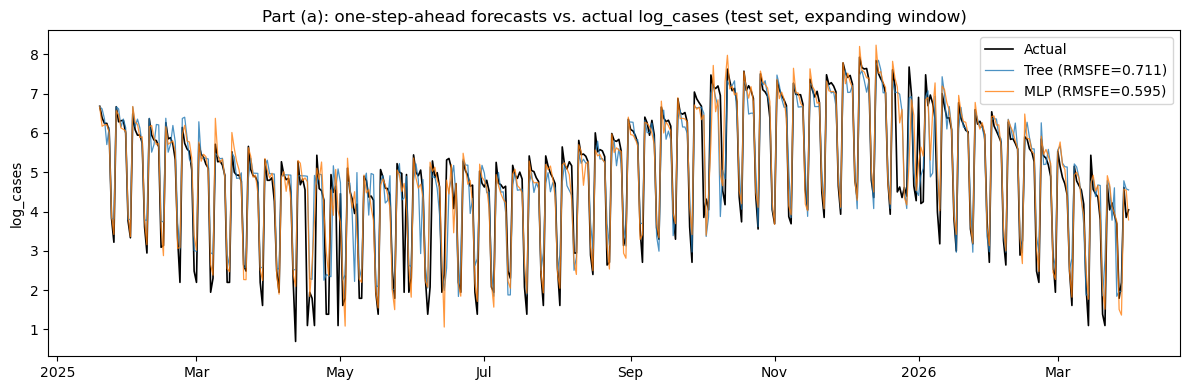

In [6]:
# Predictions are stored directly from the expanding-window loop
pred_tree_a = res_a["preds_tree"]
pred_mlp_a  = res_a["preds_mlp"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(res_a["X_test"].index, res_a["y_test"], color="black", lw=1.2, label="Actual")
ax.plot(res_a["X_test"].index, pred_tree_a, lw=0.9, alpha=0.8,
        label=f"Tree (RMSFE={res_a['rmsfe_tree']:.3f})")
ax.plot(res_a["X_test"].index, pred_mlp_a,  lw=0.9, alpha=0.8,
        label=f"MLP (RMSFE={res_a['rmsfe_mlp']:.3f})")
ax.set_title("Part (a): one-step-ahead forecasts vs. actual log_cases (test set, expanding window)")
ax.set_ylabel("log_cases")
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.tight_layout()
plt.show()


## Part (b) - lags of `log_cases` + lagged covariates

Age composition: RKI age groups, log-transformed (as in Project 1),
plus temperature and the start-of-week dummy.


In [7]:
covariate_cols = (
    [f"log_{c}" for c in cases_by_age.columns]
    + ["temp_mean", "start_of_week"]
)

X_b, y_b = make_lagged_matrix(data, "log_cases", covariate_cols=covariate_cols, n_lags=10)
res_b = fit_and_evaluate(X_b, y_b, label="Part (b) -- lags + covariates")


=== Part (b) -- lags + covariates ===
  n_train(+val)=1746  n_test=437  n_features=100
  Best tree : depth=5, min_leaf=10
  Best MLP  : arch=(64, 32)
  Expanding-window re-estimation over 437 test steps ...
    step  100/437
    step  200/437
    step  300/437
    step  400/437
    step  437/437
  Regression tree  (depth=   5, min_leaf=10): RMSFE(test) = 0.7252
  Neural network   (hidden=  (64, 32)):           RMSFE(test) = 0.5715


### Forecast vs. actual (test period)


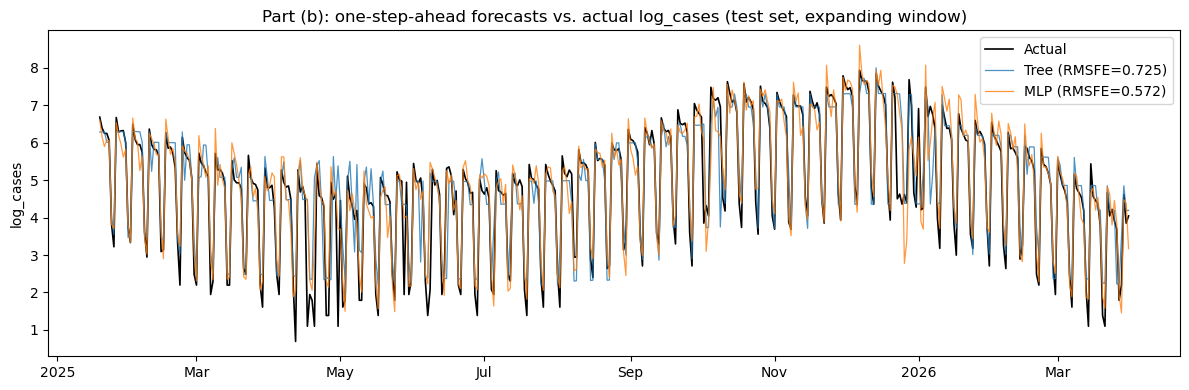

In [8]:
# Predictions are stored directly from the expanding-window loop
pred_tree_b = res_b["preds_tree"]
pred_mlp_b  = res_b["preds_mlp"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(res_b["X_test"].index, res_b["y_test"], color="black", lw=1.2, label="Actual")
ax.plot(res_b["X_test"].index, pred_tree_b, lw=0.9, alpha=0.8,
        label=f"Tree (RMSFE={res_b['rmsfe_tree']:.3f})")
ax.plot(res_b["X_test"].index, pred_mlp_b,  lw=0.9, alpha=0.8,
        label=f"MLP (RMSFE={res_b['rmsfe_mlp']:.3f})")
ax.set_title("Part (b): one-step-ahead forecasts vs. actual log_cases (test set, expanding window)")
ax.set_ylabel("log_cases")
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.tight_layout()
plt.show()


### Why these hyperparameters? Train / validation / test RMSFE vs tree depth


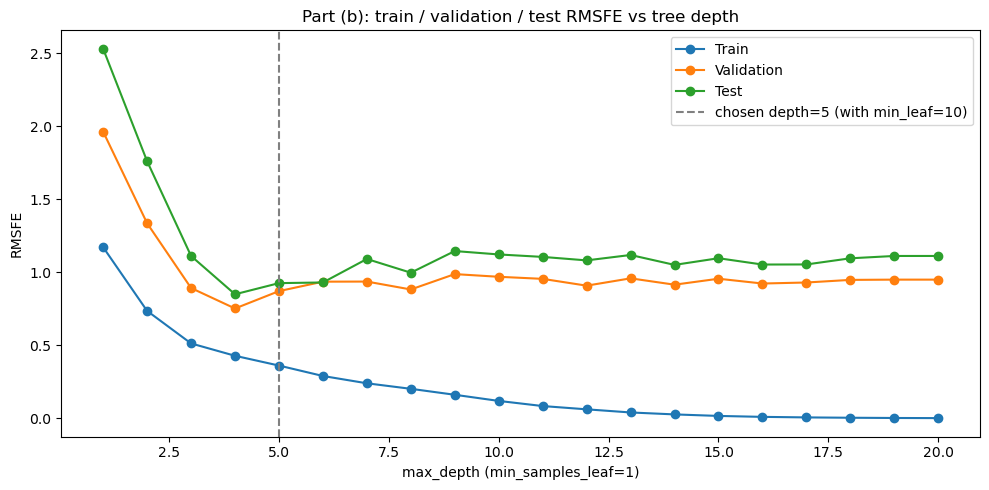

In [9]:
n_ = len(X_b)
test_start = int(0.8 * n_)
val_start  = int(0.8 * test_start)
X_tr_b, y_tr_b   = X_b.iloc[:val_start],          y_b.iloc[:val_start]
X_val_b, y_val_b = X_b.iloc[val_start:test_start], y_b.iloc[val_start:test_start]
X_te_b, y_te_b   = X_b.iloc[test_start:],          y_b.iloc[test_start:]

depths = range(1, 21)
train_rmse, val_rmse, test_rmse = [], [], []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, min_samples_leaf=1, random_state=0).fit(X_tr_b, y_tr_b)
    train_rmse.append(np.sqrt(np.mean((y_tr_b - m.predict(X_tr_b)) ** 2)))
    val_rmse.append(np.sqrt(np.mean((y_val_b - m.predict(X_val_b)) ** 2)))
    test_rmse.append(np.sqrt(np.mean((y_te_b - m.predict(X_te_b)) ** 2)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(depths), train_rmse, marker="o", label="Train")
ax.plot(list(depths), val_rmse,   marker="o", label="Validation")
ax.plot(list(depths), test_rmse,  marker="o", label="Test")
ax.axvline(res_b["tree_depth"], color="gray", ls="--",
           label=f"chosen depth={res_b['tree_depth']} (with min_leaf={res_b['tree_min_leaf']})")
ax.set_xlabel("max_depth (min_samples_leaf=1)")
ax.set_ylabel("RMSFE")
ax.set_title("Part (b): train / validation / test RMSFE vs tree depth")
ax.legend()
plt.tight_layout()
plt.show()


## Summary of results

Collecting the headline numbers from (a) and (b) in one place, together with
a naive persistence baseline (tomorrow's forecast = today's value), to give a
sense of scale for the report.


In [10]:
naive_pred = res_a["X_test"]["log_cases_lag0"]
rmsfe_naive = np.sqrt(np.mean((res_a["y_test"] - naive_pred) ** 2))

summary = pd.DataFrame({
    "Method":   ["Naive (persistence)", "Regression tree", "Neural network",
                  "Regression tree", "Neural network"],
    "Features": ["-", "lags only (a)", "lags only (a)",
                  "lags + covariates (b)", "lags + covariates (b)"],
    "RMSFE":    [rmsfe_naive, res_a["rmsfe_tree"], res_a["rmsfe_mlp"],
                  res_b["rmsfe_tree"], res_b["rmsfe_mlp"]],
})
summary["RMSFE"] = summary["RMSFE"].round(4)
print(summary.to_string(index=False))


             Method              Features  RMSFE
Naive (persistence)                     - 1.6953
    Regression tree         lags only (a) 0.7107
     Neural network         lags only (a) 0.5951
    Regression tree lags + covariates (b) 0.7252
     Neural network lags + covariates (b) 0.5715


## Quick look ahead: root-node split for each tree

A cheap sanity check ahead of the variable-importance discussion in (c)/(d): which
feature does each fitted tree split on first?


In [11]:
print("Part (a) tree root split:", X_a.columns[res_a['tree'].tree_.feature[0]])
print("Part (b) tree root split:", X_b.columns[res_b['tree'].tree_.feature[0]])


Part (a) tree root split: log_cases_lag6
Part (b) tree root split: log_cases_lag6


## Part (c) - Variable importance via permutation importance

Permutation importance (Molnar, Ch. 8.5) is model-agnostic: for each feature, shuffle
its values in the test set and measure how much the score degrades. We use
`scoring="neg_root_mean_squared_error"`, so each importance value is directly the
increase in test RMSFE caused by destroying that feature's information, i.e. the same
units as the headline numbers from Part (b). Applied to both fitted Part (b) models
(`res_b["tree"]` and `res_b["mlp"]`) so the rankings are directly comparable.


In [12]:
from sklearn.inspection import permutation_importance

# Tree (raw features)
perm_tree = permutation_importance(
    res_b["tree"], res_b["X_test"], res_b["y_test"],
    n_repeats=10, scoring="neg_root_mean_squared_error", random_state=0
)

# MLP (needs the same scaling used at fit time)
X_test_scaled = res_b["scaler"].transform(res_b["X_test"])
perm_mlp = permutation_importance(
    res_b["mlp"], X_test_scaled, res_b["y_test"],
    n_repeats=10, scoring="neg_root_mean_squared_error", random_state=0
)

imp_tree = pd.Series(perm_tree.importances_mean, index=X_b.columns).sort_values(ascending=False)
imp_mlp  = pd.Series(perm_mlp.importances_mean,  index=X_b.columns).sort_values(ascending=False)

print("Top 10 -- Regression tree (RMSFE increase when shuffled):")
print(imp_tree.head(10))
print("\nTop 10 -- Neural network (RMSFE increase when shuffled):")
print(imp_mlp.head(10))


Top 10 -- Regression tree (RMSFE increase when shuffled):
log_cases_lag6            1.498343
log_cases_A60_A79_lag2    0.091240
start_of_week_lag5        0.033689
log_cases_A15_A34_lag5    0.033655
log_cases_A80plus_lag0    0.033588
log_cases_lag0            0.021062
log_cases_A15_A34_lag0    0.015811
log_cases_A35_A59_lag0    0.001232
log_cases_A60_A79_lag6    0.000000
log_cases_A80plus_lag6    0.000000
dtype: float64

Top 10 -- Neural network (RMSFE increase when shuffled):
start_of_week_lag0        0.529745
start_of_week_lag6        0.444072
start_of_week_lag3        0.390882
start_of_week_lag5        0.333043
start_of_week_lag4        0.295467
log_cases_A80plus_lag0    0.277812
log_cases_A80plus_lag4    0.243167
start_of_week_lag9        0.207498
start_of_week_lag8        0.187980
start_of_week_lag7        0.166706
dtype: float64


### Permutation importance, visualized


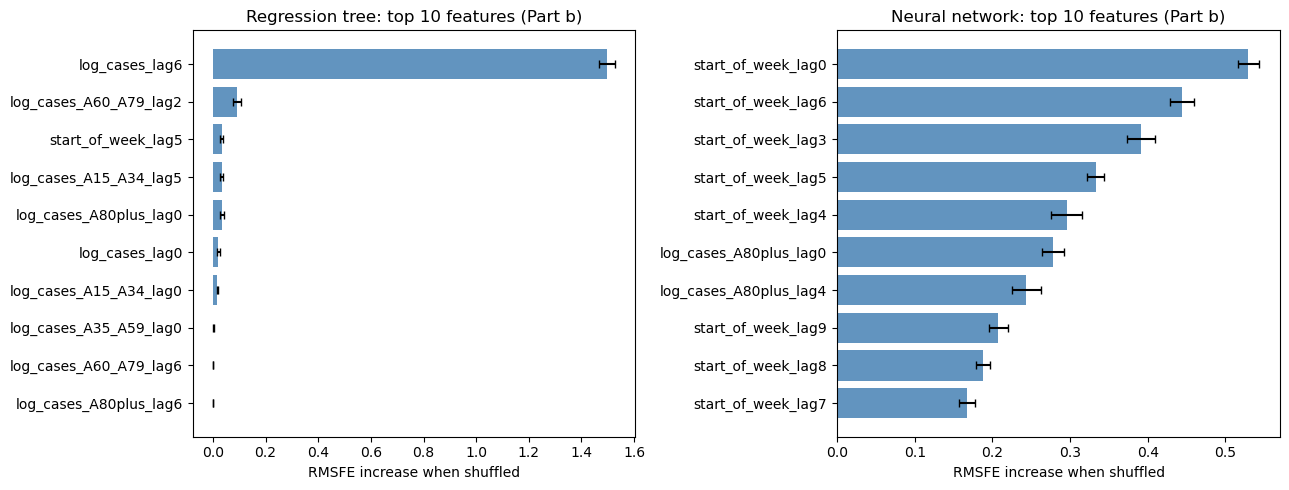

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, perm, title in zip(
    axes,
    [perm_tree, perm_mlp],
    ["Regression tree", "Neural network"],
):
    imp = pd.Series(perm.importances_mean, index=X_b.columns)
    std = pd.Series(perm.importances_std,  index=X_b.columns)
    top = imp.sort_values(ascending=False).head(10)
    ax.barh(top.index[::-1], top.values[::-1],
            xerr=std.loc[top.index][::-1], color="steelblue", alpha=0.85, capsize=3)
    ax.set_title(f"{title}: top 10 features (Part b)")
    ax.set_xlabel("RMSFE increase when shuffled")

plt.tight_layout()
plt.show()


## Supporting check for (d): weekly pattern in `log_cases`

Whether case counts genuinely differ by day of week is the mechanism behind
`start_of_week` showing up as important for the network.


In [14]:
dow = data.groupby(data.index.dayofweek)["log_cases"].agg(["mean", "std"])
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(dow)


         mean       std
Mon  7.957420  2.087694
Tue  8.052660  2.234170
Wed  7.992455  2.279982
Thu  7.880716  2.301661
Fri  7.762124  2.280336
Sat  6.363783  2.864489
Sun  5.857178  2.773922


## Supporting check for (d): does a weekly pattern remain in the residuals?

The raw series clearly differs by weekday (above). Splitting each part-(b)
model's test-set residuals by weekday checks whether either method still
leaves that pattern on the table.


         Tree       MLP
Mon -0.051498 -0.053029
Tue  0.008317 -0.041247
Wed -0.074734  0.010815
Thu  0.024392 -0.016984
Fri -0.281852 -0.157337
Sat -0.458443 -0.202300
Sun  0.186796 -0.081740


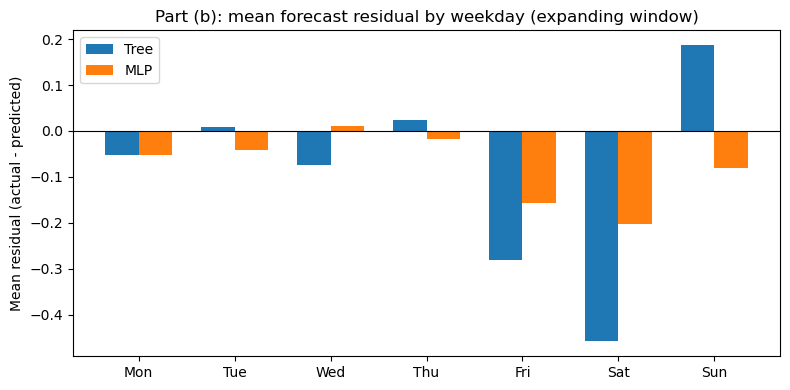

In [15]:
resid_tree_b = res_b["y_test"].values - pred_tree_b
resid_mlp_b  = res_b["y_test"].values - pred_mlp_b

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
resid_by_dow = pd.DataFrame(
    {"Tree": resid_tree_b, "MLP": resid_mlp_b},
    index=res_b["y_test"].index,
)
resid_means = resid_by_dow.groupby(resid_by_dow.index.dayofweek).mean()
resid_means.index = [dow_names[i] for i in resid_means.index]
print(resid_means)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(7)
width = 0.35
ax.bar(x - width / 2, resid_means["Tree"], width, label="Tree")
ax.bar(x + width / 2, resid_means["MLP"],  width, label="MLP")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dow_names)
ax.set_ylabel("Mean residual (actual - predicted)")
ax.set_title("Part (b): mean forecast residual by weekday (expanding window)")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
from scipy import stats

def dm_test(actual, pred1, pred2):
    e1 = np.asarray(actual) - np.asarray(pred1)
    e2 = np.asarray(actual) - np.asarray(pred2)
    d  = e1**2 - e2**2
    DM = d.mean() / np.sqrt(d.var(ddof=1) / len(d))
    p  = 2 * stats.norm.sf(abs(DM))
    return float(DM), float(p)

# Align test sets by index (safe in case dropna differs between a and b)
idx_a = res_a["y_test"].index
idx_b = res_b["y_test"].index
common_idx = idx_a.intersection(idx_b)

act  = res_a["y_test"].loc[common_idx].values
pt_a = res_a["preds_tree"][idx_a.isin(common_idx)]
pm_a = res_a["preds_mlp"] [idx_a.isin(common_idx)]
pt_b = res_b["preds_tree"][idx_b.isin(common_idx)]
pm_b = res_b["preds_mlp"] [idx_b.isin(common_idx)]

comparisons = [
    ("Tree (a)",  "MLP (a)",  act, pt_a, pm_a),
    ("Tree (b)",  "MLP (b)",  act, pt_b, pm_b),
    ("Tree (a)",  "Tree (b)", act, pt_a, pt_b),
    ("MLP (a)",   "MLP (b)",  act, pm_a, pm_b),
]

print("Diebold-Mariano tests  (H0: equal predictive accuracy, squared loss, two-sided)\n")
print(f"{'Method 1':<13} vs {'Method 2':<13}  {'DM stat':>8}  {'p-value':>8}  Sig.")
print("-" * 62)
for m1, m2, act_, p1, p2 in comparisons:
    DM, p = dm_test(act_, p1, p2)
    stars  = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "n.s."
    better = m2 if DM > 0 else m1
    print(f"{m1:<13} vs {m2:<13}  {DM:>8.3f}  {p:>8.4f}  {stars:<4}  → {better} better")

Diebold-Mariano tests  (H0: equal predictive accuracy, squared loss, two-sided)

Method 1      vs Method 2        DM stat   p-value  Sig.
--------------------------------------------------------------
Tree (a)      vs MLP (a)           2.949    0.0032  ***   → MLP (a) better
Tree (b)      vs MLP (b)           3.325    0.0009  ***   → MLP (b) better
Tree (a)      vs Tree (b)         -0.968    0.3332  n.s.  → Tree (a) better
MLP (a)       vs MLP (b)           0.842    0.3996  n.s.  → MLP (b) better
